# Simple MNIST convnet

**Author:** [fchollet](https://twitter.com/fchollet)<br>
**Date created:** 2015/06/19<br>
**Last modified:** 2020/04/21<br>
**Description:** A simple convnet that achieves ~99% test accuracy on MNIST.

## Setup

In [1]:
import numpy as np
import keras
from keras import layers

## Prepare the data

In [2]:
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1) #1은 흑백, 3은 컬러

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


## Build the model

In [3]:
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        #32는 필터의 개수를 뜻함. 파라미터 값과 정비례. 많아지면 과적합.
        layers.MaxPooling2D(pool_size=(2, 2)),
        #MaxPooling은 파라미터가 필요없기 때문에 0.
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

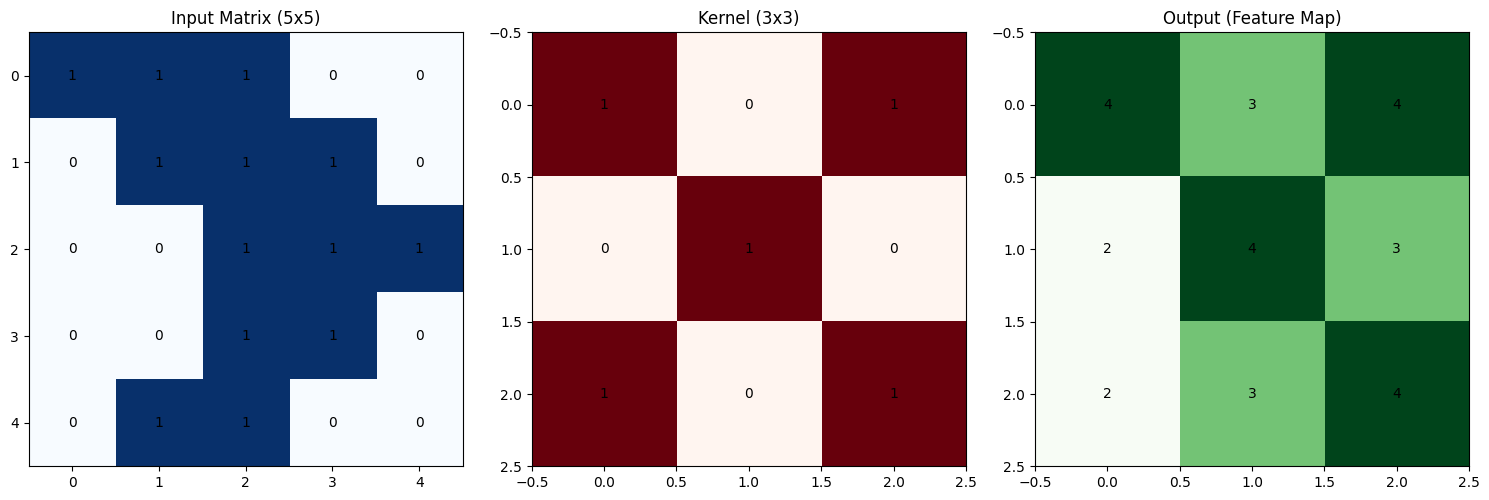

In [20]:
# @title
import matplotlib.pyplot as plt
import numpy as np

def visual_conv_step():
    # 간단한 5x5 이미지와 3x3 필터 설정
    image = np.array([
        [1, 1, 1, 0, 0],
        [0, 1, 1, 1, 0],
        [0, 0, 1, 1, 1],
        [0, 0, 1, 1, 0],
        [0, 1, 1, 0, 0]
    ])
    kernel = np.array([
        [1, 0, 1],
        [0, 1, 0],
        [1, 0, 1]
    ])

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # 입력 이미지
    ax[0].imshow(image, cmap='Blues')
    for (j,i), label in np.ndenumerate(image):
        ax[0].text(i,j,label,ha='center',va='center', color='black')
    ax[0].set_title("Input Matrix (5x5)")

    # 커널(필터)
    ax[1].imshow(kernel, cmap='Reds')
    for (j,i), label in np.ndenumerate(kernel):
        ax[1].text(i,j,label,ha='center',va='center', color='black')
    ax[1].set_title("Kernel (3x3)")

    # 연산 결과 (3x3)
    result = np.array([
        [4, 3, 4],
        [2, 4, 3],
        [2, 3, 4]
    ])
    ax[2].imshow(result, cmap='Greens')
    for (j,i), label in np.ndenumerate(result):
        ax[2].text(i,j,label,ha='center',va='center', color='black')
    ax[2].set_title("Output (Feature Map)")

    plt.tight_layout()
    plt.show()

visual_conv_step()

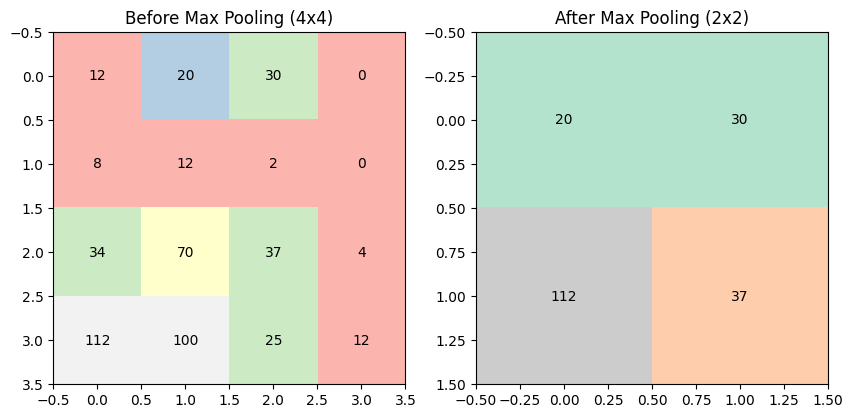

In [21]:
# @title
def visual_pooling():
    # 4x4 입력 데이터
    input_mat = np.array([
        [12, 20, 30, 0],
        [8, 12, 2, 0],
        [34, 70, 37, 4],
        [112, 100, 25, 12]
    ])

    # 2x2 Max Pooling 결과
    output_mat = np.array([
        [20, 30],
        [112, 37]
    ])

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(input_mat, cmap='Pastel1')
    for (j,i), label in np.ndenumerate(input_mat):
        ax[0].text(i,j,label,ha='center',va='center')
    ax[0].set_title("Before Max Pooling (4x4)")

    ax[1].imshow(output_mat, cmap='Pastel2')
    for (j,i), label in np.ndenumerate(output_mat):
        ax[1].text(i,j,label,ha='center',va='center')
    ax[1].set_title("After Max Pooling (2x2)")

    plt.show()

visual_pooling()

### 딥러닝 레이어별 파라미터 계산 공식 요약

| 레이어 타입 | 파라미터 계산 공식 |
| :--- | :--- |
| **Conv2D** | `(kernel_w * kernel_h * input_channels + 1) * number_of_filters` |
| **Dense** | `(input_units + 1) * output_units` |
| **Pooling/Flatten** | `0` (학습 파라미터 없음) |

**핵심 포인트:**
- `+ 1`은 각 필터나 뉴런에 더해지는 **편향(Bias)** 값을 의미합니다.
- **Conv2D**의 경우, 입력 채널 수(흑백 1, 컬러 3)가 계산에 포함되는 것이 특징입니다.
*   MaxPooling2D, Flatten, Dropout: 이 층들은 학습해야 할 가중치가 없으므로 파라미터 수가 0입니다.



## Train the model

In [4]:
batch_size = 128
epochs = 15

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8821 - loss: 0.3848 - val_accuracy: 0.9763 - val_loss: 0.0864
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9647 - loss: 0.1187 - val_accuracy: 0.9832 - val_loss: 0.0577
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9725 - loss: 0.0877 - val_accuracy: 0.9873 - val_loss: 0.0492
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9777 - loss: 0.0734 - val_accuracy: 0.9893 - val_loss: 0.0425
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9798 - loss: 0.0645 - val_accuracy: 0.9892 - val_loss: 0.0386
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9827 - loss: 0.0559 - val_accuracy: 0.9913 - val_loss: 0.0360
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9834 - loss: 0.0522 - val_accuracy: 0.9903 - val_loss: 0.0325
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9851 - loss: 0.0477 - val_accuracy: 

## Evaluate the trained model

In [5]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.0248250775039196
Test accuracy: 0.9909999966621399


## Relevant Chapters from Deep Learning with Python
- [Chapter 8: Image classification](https://deeplearningwithpython.io/chapters/chapter08_image-classification)
